In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (accuracy_score,
precision_score, recall_score, f1_score,
roc_auc_score)
print("Ready!")

Ready!


In [2]:
X_train = np.load('saved_models/X_train_w2v.npy')
X_test = np.load('saved_models/X_test_w2v.npy')
y_train = np.load('saved_models/y_train.npy')
y_test = np.load('saved_models/y_test.npy')
rf_model = pickle.load(
open('saved_models/rf_model.pkl','rb'))
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]
rf_results = {
'Model' : 'Random Forest',
'Type' : 'ML',
'Accuracy' : accuracy_score(y_test, rf_pred),
'Precision': precision_score(y_test, rf_pred),
'Recall' : recall_score(y_test, rf_pred),
'F1' : f1_score(y_test, rf_pred),
'ROC-AUC' : roc_auc_score(y_test, rf_prob),
}
print("Random Forest results loaded!")
print(f"RF Accuracy: {rf_results['Accuracy']*100:.2f}%")

Random Forest results loaded!
RF Accuracy: 96.78%


In [3]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
df = pd.read_csv('cleaned_data.csv')
tokenizer= pickle.load(
open('saved_models/gru_tokenizer.pkl','rb'))
gru_model = load_model('saved_models/gru_model.h5')
sequences = tokenizer.texts_to_sequences(
df['clean_text'].astype(str))
X_pad_all = pad_sequences(sequences,
maxlen=300, truncating='post')
from sklearn.model_selection import train_test_split
_, X_test_seq, _, y_test_seq = train_test_split(
X_pad_all, df['label'].values,
test_size=0.2, random_state=42,
stratify=df['label'])
gru_prob = gru_model.predict(X_test_seq).flatten()
gru_pred = (gru_prob >= 0.5).astype(int)
gru_results = {
'Model' : 'GRU',
'Type' : 'DL',
'Accuracy' : accuracy_score(y_test_seq, gru_pred),
'Precision': precision_score(y_test_seq, gru_pred),
'Recall' : recall_score(y_test_seq, gru_pred),
'F1' : f1_score(y_test_seq, gru_pred),
'ROC-AUC' : roc_auc_score(y_test_seq, gru_prob),
}
print("GRU results loaded!")
print(f"GRU Accuracy: {gru_results['Accuracy']*100:.2f}%")

277/277 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step
GRU results loaded!
GRU Accuracy: 99.67%


In [4]:
results_df = pd.DataFrame([rf_results, gru_results])
print("=" * 60)
print(" MODEL COMPARISON — ESHAN (Member 3)")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)


 MODEL COMPARISON — ESHAN (Member 3)
        Model Type  Accuracy  Precision   Recall       F1  ROC-AUC
Random Forest   ML  0.967778   0.969911 0.963343 0.966616 0.995426
          GRU   DL  0.996721   0.995112 0.998132 0.996620 0.999467


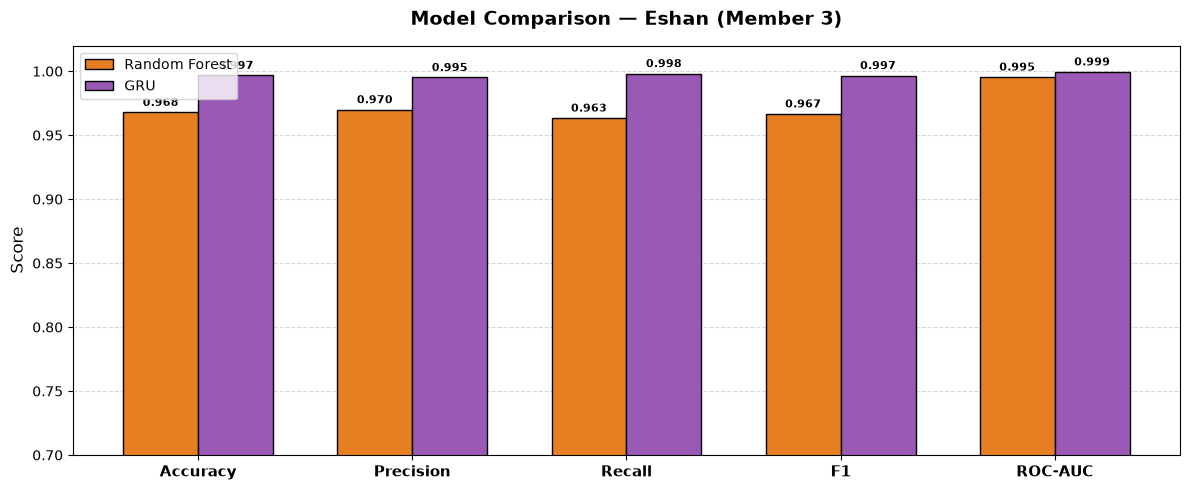

Comparison chart saved!


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

# Plot initialization
fig, ax = plt.subplots(figsize=(12, 5))

# Plot bars
bars1 = ax.bar(x - width/2, [rf_results[m] for m in metrics], width, 
               label='Random Forest', color='#e67e22', edgecolor='black')
bars2 = ax.bar(x + width/2, [gru_results[m] for m in metrics], width, 
               label='GRU', color='#9b59b6', edgecolor='black')

# Formatting axis & labels
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylim(0.7, 1.02)
ax.set_title('Model Comparison — Eshan (Member 3)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=10, loc='upper left')

# Background grid for better readability
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Value annotations for Random Forest bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Value annotations for GRU bars
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Save and show plot
plt.tight_layout()
plt.savefig('m3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison chart saved!")

In [7]:
best = max([rf_results, gru_results],
key=lambda x: x['F1'])
print("=" * 50)
print(" BEST MODEL SELECTION — ESHAN")
print("=" * 50)
print(f"Best Model : {best['Model']}")
print(f"Best F1-Score : {best['F1']:.4f}")
print(f"Best Accuracy : {best['Accuracy']*100:.2f}%")
print(f"Best ROC-AUC : {best['ROC-AUC']:.4f}")
print("=" * 50)
print(f"\nThis model will be used in the final app.")


 BEST MODEL SELECTION — ESHAN
Best Model : GRU
Best F1-Score : 0.9966
Best Accuracy : 99.67%
Best ROC-AUC : 0.9995

This model will be used in the final app.
